# MF6PQC reproduction of PHT3D Example 9

The contour levels, units, coordinates, and target time match `main_case9.ipynb`. The second cell compares the MF6PQC arrays with the archived official PHT3D output at day 360.

In [1]:
import io
import sys
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

sys.dont_write_bytecode = True
CASE_NAME = "ex009_PHT3D_09"
candidates = (
    candidate
    for base in (Path.cwd(), *Path.cwd().parents)
    for candidate in (base, base / "examples" / CASE_NAME)
)
CASE_DIR = next(
    (
        path.resolve()
        for path in candidates
        if path.name == CASE_NAME and (path / "modflow_model.py").is_file()
    ),
    None,
)
if CASE_DIR is None:
    raise FileNotFoundError(f"Cannot locate examples/{CASE_NAME} from {Path.cwd()}")
EXAMPLES_DIR = CASE_DIR.parent
if str(EXAMPLES_DIR) not in sys.path:
    sys.path.insert(0, str(EXAMPLES_DIR))

from example_utils import runtime_path, time_indices

INPUT_DIR = CASE_DIR / "input_data"
OUTPUT_DIR = runtime_path(CASE_DIR / "run.py", "output")


def read_saved_results(output_dir):
    names = ("results.npy", "results_headings.txt", "results_times.npy")
    if all((output_dir / name).is_file() for name in names):
        contents = {name: (output_dir / name).read_bytes() for name in names}
    elif (output_dir / "saved_results.zip").is_file():
        with zipfile.ZipFile(output_dir / "saved_results.zip") as archive:
            contents = {name: archive.read(name) for name in names}
        print("Reading archived MF6PQC results from saved_results.zip")
    else:
        missing = [name for name in names if not (output_dir / name).is_file()]
        raise FileNotFoundError(f"Missing saved results in {output_dir}: {missing}")
    values = np.load(io.BytesIO(contents["results.npy"]), allow_pickle=False)
    times = np.load(io.BytesIO(contents["results_times.npy"]), allow_pickle=False)
    headings = contents["results_headings.txt"].decode("utf-8-sig").splitlines()
    headings = [name.strip() for name in headings]
    if not headings or any(not name for name in headings) or len(set(headings)) != len(headings):
        raise ValueError("Result headings must be nonempty and unique")
    if values.ndim != 3 or times.ndim != 1 or values.shape[:2] != (times.size, len(headings)):
        raise ValueError("Saved result dimensions do not match their headings and times")
    if not np.isfinite(times).all() or np.any(np.diff(times) <= 0):
        raise ValueError("Saved times must be finite and strictly increasing")
    return values, headings, times

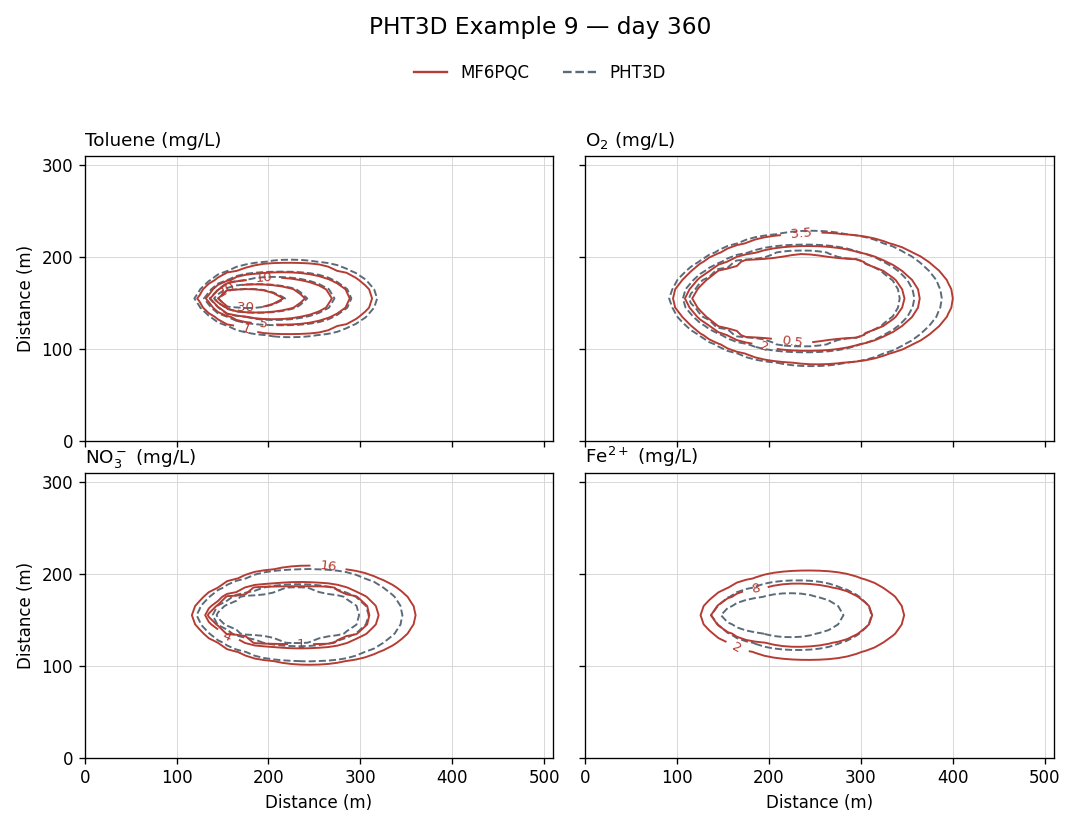

In [2]:
target_time = 360.0
nrow, ncol = 31, 51
cell_size = 10.0
plot_specs = [
    ("Toluene", 92.14, "Toluene", [1, 5, 10, 20, 30]),
    ("Oxygen", 15.999, r"O$_2$", [0.5, 2.0, 3.5]),
    ("Nitrate", 62.005, r"NO$_3^-$", [1, 4, 16]),
    ("Fe2", 55.845, r"Fe$^{2+}$", [2, 8, 32]),
]

results, headings, result_times = read_saved_results(OUTPUT_DIR)
reference = np.load(INPUT_DIR / "PHT3D_09_results.npy", allow_pickle=False)
required = {"time_days", *(name for name, *_ in plot_specs)}
if not required.issubset(reference.dtype.names or ()):
    raise ValueError(f"Reference data must contain {sorted(required)}")
reference_times = reference["time_days"]
if reference_times.ndim != 1 or not np.isfinite(reference_times).all():
    raise ValueError("Reference times must be a finite one-dimensional array")
if np.any(np.diff(reference_times) <= 0):
    raise ValueError("Reference times must be strictly increasing")
if results.shape[2] != nrow * ncol:
    raise ValueError(f"Expected {nrow * ncol} cells, got {results.shape[2]}")

time_index = int(time_indices(result_times, [target_time])[0])
official_index = int(time_indices(reference_times, [target_time])[0])
mf6pqc_fields, official_fields = {}, {}
for name, molar_mass, _, _ in plot_specs:
    if name not in headings:
        raise ValueError(f"Missing MF6PQC output: {name}")
    if reference[name].shape != (reference_times.size, nrow, ncol):
        raise ValueError(f"Unexpected reference grid for {name}: {reference[name].shape}")
    modeled = results[time_index, headings.index(name)].reshape(nrow, ncol)
    official = reference[name][official_index]
    if not np.isfinite(modeled).all() or not np.isfinite(official).all():
        raise ValueError(f"Non-finite concentrations for {name} at day {target_time:g}")
    mf6pqc_fields[name] = modeled * 1000 * molar_mass
    official_fields[name] = official * 1000 * molar_mass

x = (np.arange(ncol) + 0.5) * cell_size
y = (np.arange(nrow) + 0.5) * cell_size
X, Y = np.meshgrid(x, y)
model_color, reference_color = "#B63B32", "#596A78"
fig, axes = plt.subplots(2, 2, figsize=(9.0, 6.8), sharex=True, sharey=True)
for ax, (name, _, title, levels) in zip(axes.flat, plot_specs, strict=True):
    has_contours = False
    for values, color, linestyle in (
        (official_fields[name], reference_color, "--"),
        (mf6pqc_fields[name], model_color, "-"),
    ):
        visible_levels = [level for level in levels if values.min() < level < values.max()]
        if visible_levels:
            contours = ax.contour(
                X,
                Y,
                values,
                levels=visible_levels,
                colors=color,
                linestyles=linestyle,
                linewidths=1.15,
            )
            if linestyle == "-":
                ax.clabel(contours, fmt="%g", fontsize=8, inline=True)
            has_contours = True
    if not has_contours:
        ax.text(0.5, 0.5, "No contours at the listed levels", ha="center", transform=ax.transAxes)
    ax.set_title(f"{title} (mg/L)", loc="left", fontsize=11)
    ax.set(xlim=(0, ncol * cell_size), ylim=(0, nrow * cell_size), aspect="equal")
    ax.set_xticks(np.arange(0, 501, 100))
    ax.set_yticks(np.arange(0, 301, 100))
    ax.grid(True, color="0.85", linewidth=0.6)
    ax.set_axisbelow(True)

for ax in axes[:, 0]:
    ax.set_ylabel("Distance (m)")
for ax in axes[-1]:
    ax.set_xlabel("Distance (m)")
fig.suptitle(f"PHT3D Example 9 — day {target_time:g}", fontsize=14, y=0.98)
fig.legend(
    handles=[
        Line2D([], [], color=model_color, lw=1.4, label="MF6PQC"),
        Line2D([], [], color=reference_color, lw=1.4, ls="--", label="PHT3D"),
    ],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.94),
    ncol=2,
    frameon=False,
)
fig.tight_layout(rect=(0, 0, 1, 0.90))
plt.show()

In [3]:
print(f"Day {target_time:g} comparison with PHT3D (all {nrow * ncol} cells)")
print(
    f"{'Variable':<10} {'RMSE (mg/L)':>14} {'MAE (mg/L)':>14} {'R2':>10} {'Max MF6PQC':>14} {'Max PHT3D':>14}"
)
comparison = []
for name, _, _, _ in plot_specs:
    modeled = mf6pqc_fields[name]
    official = official_fields[name]
    difference = modeled - official
    rmse = float(np.sqrt(np.mean(difference**2)))
    mae = float(np.mean(np.abs(difference)))
    denominator = float(np.sum((official - official.mean()) ** 2))
    r2 = 1 - float(np.sum(difference**2)) / denominator if denominator > 0 else np.nan
    comparison.append({"variable": name, "RMSE_mg_L": rmse, "MAE_mg_L": mae, "R2": r2})
    r2_text = f"{r2:.6f}" if np.isfinite(r2) else "n/a"
    print(
        f"{name:<10} {rmse:14.6f} {mae:14.6f} {r2_text:>10} {modeled.max():14.6f} {official.max():14.6f}"
    )

Day 360 comparison with PHT3D (all 1581 cells)
Variable      RMSE (mg/L)     MAE (mg/L)         R2     Max MF6PQC      Max PHT3D
Toluene          0.213412       0.062664   0.998379      96.801396      97.682046
Oxygen           0.121787       0.048836   0.991473       3.990488       3.999935
Nitrate          0.918999       0.351885   0.964566      19.945200      20.003480
Fe2              2.464337       0.707696   0.337558      24.925254      24.972081
